In [5]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [6]:
import requests
import json

def get_weather(loc):
    """
    Function to query content weather.
    "param loc: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the loc parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    """

    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")

    # step 2 设置查询参数
    params={
        "q":loc,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }

    response=requests.get(url,params=params)

    data=response.json()
    return json.dumps(data)

In [7]:
get_weather("beijing")

'{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 804, "main": "Clouds", "description": "\\u9634\\uff0c\\u591a\\u4e91", "icon": "04d"}], "base": "stations", "main": {"temp": 27.94, "feels_like": 31.09, "temp_min": 27.94, "temp_max": 27.94, "pressure": 1009, "humidity": 74, "sea_level": 1009, "grnd_level": 1005}, "visibility": 10000, "wind": {"speed": 0.23, "deg": 358, "gust": 1.42}, "clouds": {"all": 100}, "dt": 1787724686, "sys": {"type": 1, "id": 9609, "country": "CN", "sunrise": 1787693776, "sunset": 1787741814}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}'

In [8]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData, Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(Integer, primary_key=True)
    city_name = Column(String(50))
    main_weather = Column(String(50))
    description = Column(String(100))
    temperature = Column(Float)
    feels_like=Column(Float)
    temp_min=Column(Float)
    temp_max=Column(Float)

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-08-26 14:23:17,561 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-08-26 14:23:17,563 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 14:23:17,565 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-08-26 14:23:17,565 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 14:23:17,568 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-08-26 14:23:17,569 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 14:23:17,571 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:23:17,572 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`weather`
2026-08-26 14:23:17,573 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 14:23:17,578 INFO sqlalchemy.engine.Engine COMMIT


In [9]:
from typing import Optional
from langchain_core.tools import tool
import requests ,json

class WeatherLoc(BaseModel):
    location:str=Field(description="the location to get the weather")

class WeatherInfo(BaseModel):
    """Extracted weather information for a city"""
    city_id:str=Field(...,description="The unique identifier for the city")
    city_name:Optional[str]=Field(description="name of the city")
    main_weather:str=Field(description="main weather condition")
    description:Optional[str]=Field(description="a detailed description of the weather")
    temperature:Optional[str]=Field(description="current temperature of the city")
    feels_like:Optional[str]=Field(description="feels-like temperature of the city")
    temp_min:Optional[str]=Field(description="minimum temperature of the city")
    temp_max:Optional[str]=Field(description="maximum temperature of the city")

@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(city_id,city_name,main_weather,description,temperature,feels_like,temp_min,temp_max):
    """insert weather information into the database"""
    session=Session()
    try:
        weather=Weather(city_id=city_id,city_name=city_name,main_weather=main_weather,
                        description=description,temperature=temperature,feels_like=feels_like,temp_min=temp_min,temp_max=temp_max)
        session.merge(weather)
        session.commit()
        return {"messages":[f"天气数据已成功存储到db"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"天气数据保存失败，错误是{e}"]}
    finally:
        session.close()
        
class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name"""
    city_name: str=Field(..., description="The name of the city to query weather information")

@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name):
    """query weather information from db by city name"""
    session=Session()
    try:
        weather_data=session.query(Weather).filter(Weather.city_name==city_name).first()
        if weather_data:
            return {
                "city_id":weather_data.city_id,
                "city_name":weather_data.city_name,
                "main_weather":weather_data.main_weather,
                "description":weather_data.description,
                "temperature":weather_data.temperature,
                "feels_like":weather_data.feels_like,
                "temp_min":weather_data.temp_min,
                "temp_max":weather_data.temp_max
            }
        else:
            return {"messages":[f"未找到城市 {city_name} 的天气信息"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因, {e}"]}
    finally:
        session.close()

In [10]:
result=query_weather_from_db.invoke({"city_name":"beijing"})
result

2026-08-26 14:23:17,768 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:23:17,773 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 14:23:17,773 INFO sqlalchemy.engine.Engine [generated in 0.00102s] {'city_name_1': 'beijing', 'param_1': 1}
2026-08-26 14:23:17,782 INFO sqlalchemy.engine.Engine ROLLBACK


{'messages': ['未找到城市 beijing 的天气信息']}

In [11]:
class SearchQuery(BaseModel):
    """the query to fetch real time infor"""
    query: str = Field(description="the query to fetch real time infor")


@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """fetch real time info from internet"""
    print("--------------")
    url = os.getenv("BAIDU_API_URL")

    payload = json.dumps(
        {
            "messages": [{"role": "user", "content": query}],
            "edition": "standard",
            "search_source": "baidu_search_v2",
            "search_recency_filter": "week",
        },
        ensure_ascii=False,
    )
    headers = {
        "Content-Type": "application/json",
        "Authorization": "Bearer " + os.getenv("BAIDU_API_KEY"),
    }

    response = requests.request(
        "POST", url, headers=headers, data=payload.encode("utf-8")
    )

    response.encoding = "utf-8"
    print(response.text)

    response = requests.get(url)
    result = json.loads(response.text)
    return result

In [12]:
tools=[fetch_real_time_info,get_weather,insert_weather_to_db,query_weather_from_db]
tools

[StructuredTool(name='fetch_real_time_info', description='fetch real time info from internet', args_schema=<class '__main__.SearchQuery'>, func=<function fetch_real_time_info at 0x0000010E1E4B6DE0>),
 StructuredTool(name='get_weather', description='从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。\n优先使用 query_weather_from_db 工具。\n\nFunction to query content weather.\n"param location: Required parameter, of type string, representing the specific city name for the weather query.\nNote that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,\nthe location parameter should be input as \'Beijing\'.\n:return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.\nThe return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.', args_schema=<class '__main__.WeatherLoc'

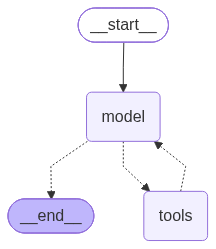

In [13]:
from langchain.agents import create_agent

graph=create_agent(llm,tools)
graph

In [16]:
def print_stream(stream):
    for sub_stream in stream:
        # print(sub_stream)
        message=sub_stream['messages'][-1]
        message.pretty_print()
        
input_messages={'messages':["你好，北京的天气怎么样"]}
print_stream(graph.stream(input_messages,stream_mode='values'))

================================ Human Message =================================

你好，北京的天气怎么样
================================== Ai Message ==================================

我来帮你查询北京的天气情况。首先让我从数据库中查询一下。
Tool Calls:
  query_weather_from_db (call_00_SAvsN49iNWaiuKGebDdF4233)
 Call ID: call_00_SAvsN49iNWaiuKGebDdF4233
  Args:
    city_name: Beijing
2026-08-26 14:26:31,503 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:26:31,531 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 14:26:31,532 INFO sqlalchemy.engine.Engine [cached since 193.8s ago] {'city_name_1': 'Beijing', 'param_

In [17]:
def print_stream(stream):
    for sub_stream in stream:
        print(sub_stream)
        # message=sub_stream['messages'][-1]
        # message.pretty_print()
        
input_messages={'messages':["你好，北京的天气怎么样"]}
print_stream(graph.stream(input_messages,stream_mode='updates'))

{'model': {'messages': [AIMessage(content='我来帮你查询北京的天气情况。首先让我从数据库中查询一下。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 882, 'total_tokens': 943, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 768}, 'prompt_cache_hit_tokens': 768, 'prompt_cache_miss_tokens': 114}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'dfe2fb0b-4cbd-4a99-990a-6e313440e922', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a03cc0-1218-7ee3-8ca6-e7e12cefb4bd-0', tool_calls=[{'name': 'query_weather_from_db', 'args': {'city_name': 'Beijing'}, 'id': 'call_00_sEpGL42mmGWg11iXUP3w1588', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 882, 'output_tokens': 61, 'total_tokens': 943, 'input_token_details': {'cache_read': 768}, 'output_token_details': {}})]}}
2026-08-26 14:26:56,4

In [18]:
def print_stream(stream):
    for sub_stream in stream:
        print(sub_stream)
        # message=sub_stream['messages'][-1]
        # message.pretty_print()
        
input_messages={'messages':["你好，北京的天气怎么样"]}
print_stream(graph.stream(input_messages,stream_mode='debug'))

{'step': 1, 'timestamp': '2026-08-26T06:27:14.461192+00:00', 'type': 'task', 'payload': {'id': '3cc7fdef-6843-fd2e-20c4-ba029eb89d1b', 'name': 'model', 'input': {'messages': [HumanMessage(content='你好，北京的天气怎么样', additional_kwargs={}, response_metadata={}, id='1e55ea48-343c-41d2-8922-ce8341bf61a0')]}, 'triggers': ('branch:to:model',), 'metadata': {'ls_integration': 'langchain_create_agent'}}}
{'step': 1, 'timestamp': '2026-08-26T06:27:15.547589+00:00', 'type': 'task_result', 'payload': {'id': '3cc7fdef-6843-fd2e-20c4-ba029eb89d1b', 'name': 'model', 'error': None, 'result': {'messages': [AIMessage(content='我来帮您查询北京的天气情况。首先让我从数据库中查询一下。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 882, 'total_tokens': 944, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 768}, 'prompt_cache_hit_tokens': 768, 'prompt_cache_miss_tokens': 114}, 'model_provider': 'openai', 'model_name': 'dee

In [19]:
async for chunk in graph.astream(input={'messages':['你好，北京的天气怎么样']},stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，北京的天气怎么样
================================== Ai Message ==================================

我来帮你查询北京的天气情况。首先让我从数据库中查询一下。
Tool Calls:
  query_weather_from_db (call_00_Xgt41w0W08r8TgV61ph04302)
 Call ID: call_00_Xgt41w0W08r8TgV61ph04302
  Args:
    city_name: Beijing
2026-08-26 14:28:10,680 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:28:10,687 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 14:28:10,688 INFO sqlalchemy.engine.Engine [cached since 292.9s ago] {'city_name_1': 'Beijing', 'param_

In [20]:
async for chunk in graph.astream(input={'messages':['你好，北京的天气怎么样']},stream_mode="values"):
    final_result=chunk
final_result['messages'][-1].pretty_print()

2026-08-26 14:28:47,158 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:28:47,159 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 14:28:47,160 INFO sqlalchemy.engine.Engine [cached since 329.4s ago] {'city_name_1': 'Beijing', 'param_1': 1}
2026-08-26 14:28:47,162 INFO sqlalchemy.engine.Engine ROLLBACK
================================== Ai Message ==================================

我已经查询到北京的天气信息了，以下是当前北京的天气情况：

🌤️ **北京天气**

- **天气状况**：阴，多云（Clouds）
- **当前温度**：27.94°C
- **体感温度**：31.09°C
- **最低温度**：27.94°C
- **最高温度**：27.94°C

目前北京是多云天气，温度接近28°C，但由于湿度等因素，体感温度达到了31°C左右，感觉会比较闷热。建议您外

In [21]:
inputs={"messages":[("human","你好，大理的天气怎么样")]}
async for chunk in graph.astream(inputs,stream_mode="updates"):
    for node,values in chunk.items():
        print(f"接收到的更新节点：{node}")
        print(values)
        print("\n\n")

接收到的更新节点：model
{'messages': [AIMessage(content='我来帮你查询大理的天气信息。首先让我从数据库中查询一下。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 883, 'total_tokens': 945, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 768}, 'prompt_cache_hit_tokens': 768, 'prompt_cache_miss_tokens': 115}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '8cb0380c-3967-4d03-9dc4-ae5ba4b11c6b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a03cc3-2fb3-7833-adf9-c3892ce047ff-0', tool_calls=[{'name': 'query_weather_from_db', 'args': {'city_name': '大理'}, 'id': 'call_00_WcZNrcX0sIJ5SQ1gOZ1z9424', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 883, 'output_tokens': 62, 'total_tokens': 945, 'input_token_details': {'cache_read': 768}, 'output_token_details': {}})]}



2026-08-26 14:30:21

In [ ]:
from langchain_core.messages import HumanMessage,AIMessageChunk

first=True
async for msg,metadata in graph.astream({"messages":["你好，帮我查询一下数据库中的沈阳的天气数据"]},stream_mode="messages"):
    if msg.content and not isinstance(msg,HumanMessage):
        print(msg.content,end="|",flush=True)
        
        if isinstance(msg,AIMessageChunk):
            if first:
                gathered=msg
                first=False
            else:
                gathered=gathered+msg
                
            if msg.tool_call_chunks:
                print(gathered.tool_calls)

我来|帮|您|查询|数据库中|沈阳|的|天气|数据|。|2026-08-26 14:34:53,662 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:34:53,664 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 14:34:53,665 INFO sqlalchemy.engine.Engine [cached since 695.9s ago] {'city_name_1': '沈阳', 'param_1': 1}
2026-08-26 14:34:53,668 INFO sqlalchemy.engine.Engine ROLLBACK
{"messages": ["未找到城市 沈阳 的天气信息"]}|数据库中|暂时|没有|找到|沈阳|的|天气|数据|。|让我|通过|实时|天气|API|来|查询|沈阳|的|天气|信息|，|然后|将其|存入|数据库|。|{"coord": {"lon": 123.4328, "lat": 41.7922}, "weather": [{"id": 800, "main": "Clear", "description": "\u6674", "icon": "01d"}], "base": "stations", 

In [27]:
from langchain_core.messages import HumanMessage,AIMessageChunk

first=True
async for msg,metadata in graph.astream({"messages":["你好，查询朝阳的天气"]},stream_mode="messages"):
    if isinstance(msg,HumanMessage):
        continue
    
    if msg.content:
        print(msg.content,end="|",flush=True)
    if isinstance(msg,AIMessageChunk):
        gathered=msg if first else gathered+msg
        first=False
    else:
        print("\n\n----------------------",gathered.tool_calls)
        first=True
        gathered=None

I|'ll| help| you| check| the| weather| for| |朝阳| (|Cha|oy|ang|).| Let| me| first| query| the| database| for| this| city|'s| weather| information|.|2026-08-26 14:43:43,289 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 14:43:43,290 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 14:43:43,291 INFO sqlalchemy.engine.Engine [cached since 1226s ago] {'city_name_1': '朝阳', 'param_1': 1}
2026-08-26 14:43:43,294 INFO sqlalchemy.engine.Engine ROLLBACK
{"messages": ["未找到城市 朝阳 的天气信息"]}|

---------------------- [{'name': 'query_weather_from_db', 'args': {'city_name': '朝阳'}, 'id': 'call_00_2B